# Image Classification for Emotion Recognition
This notebook demonstrates how to build an image classification model for emotion recognition using TensorFlow and Keras. The model is trained on a dataset of facial expressions and can be converted to different formats for deployment. The notebook show results of the model's performance, including accuracy and loss plots, and provides a sample inference using the trained model.

The notebook covers the following steps:
1. [Import Packages/Libraries](#import-packageslibraries)
2. [Data Preparation](#data-preparation)
   - [Data Loading](#data-loading)
   - [Data Preprocessing](#data-preprocessing)
     - [Data Augmentation](#data-augmentation)
     - [Data Splitting](#data-splitting)
3. [Modelling](#modelling)
4. [Evaluation and Visualisation](#evaluation-and-visualisation)
5. [Model Conversion](#model-conversion)
6. [Inference](#inference)


Resources:
- [Emotion Recognition Dataset](https://www.kaggle.com/datasets/sujaykapadnis/emotion-recognition-dataset)

## Import Packages/Libraries

In [343]:
# Import common libraries
import os  # Operating system interfaces for file/directory operations
import shutil  # High-level file operations (copy, move, delete)
import random 
from random import sample  # Random sampling functions
import numpy as np  # Numerical computing and array operations
import pandas as pd  # Data manipulation and analysis
from tqdm.notebook import tqdm as tq  # Progress bars for Jupyter notebooks
import seaborn as sns # Data visualization library based on Matplotlib
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import GlobalAveragePooling2D

# Image processing libraries
import cv2  # OpenCV for computer vision tasks
from PIL import Image  # Python Imaging Library for image manipulation
from skimage import io  # Image input/output operations
from skimage.transform import rotate, AffineTransform, warp  # Image transformations
from skimage.util import img_as_ubyte  # Image type conversion
from skimage.exposure import adjust_gamma  # Gamma correction

# Libraries for development models
from sklearn.model_selection import train_test_split  # Dataset splitting utilities
import tensorflow as tf  # End-to-end machine learning platform
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Image data generators and augmentation
from tensorflow.keras.optimizers.legacy import  Adam # Optimization algorithms
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization  # Neural network layer types
from tensorflow.keras.models import Sequential  # Linear stack of layers
from tensorflow.keras.applications import MobileNetV2  # Pre-trained models for image classification

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau # Training monitoring utilities

# Visualization and warnings
import matplotlib.pyplot as plt  # Plotting and visualization
import warnings  # Handle warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  # Suppress future warnings

In [12]:
# check the version of TensorFlow
print(tf.__version__)

2.15.0


## Data Preparation

### Data Loading

In [69]:
import kagglehub

source_path = kagglehub.dataset_download("sujaykapadnis/emotion-recognition-dataset")

# Define the destination path
destination_path = 'data'

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Move the dataset to the destination directory
shutil.move(source_path, destination_path)

print(f"Dataset downloaded and moved to {destination_path}")

100%|██████████| 1.98G/1.98G [05:13<00:00, 6.78MB/s] 

Extracting files...


Dataset downloaded and moved to data


In [97]:
# Function to check size of images in a directory
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0
    all_subdir = []
 
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        all_subdir.append(subdir)
        total_images += num_images
 
        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")
        print("---------------")
 
    print(f"\nAll label directories: {all_subdir}")
    print(f"\nTotal: {total_images} Files")


path_dataset = 'data/1/dataset'    
print_images_resolution(path_dataset)    

Surprise_augmented: 2000
- (224, 224)
---------------
Happy: 3740
- (177, 190)
- (277, 277)
- (189, 164)
- (176, 231)
- (1159, 1159)
- (310, 310)
- (336, 448)
- (631, 631)
- (129, 155)
- (613, 613)
- (238, 327)
- (242, 297)
- (1495, 1495)
- (259, 386)
- (314, 401)
- (679, 679)
- (377, 377)
- (137, 216)
- (239, 263)
- (712, 712)
- (423, 838)
- (245, 343)
- (184, 184)
- (410, 410)
- (389, 473)
- (61, 113)
- (259, 363)
- (178, 289)
- (1292, 1292)
- (217, 217)
- (510, 619)
- (112, 200)
- (65, 88)
- (250, 250)
- (47, 70)
- (226, 307)
- (50, 81)
- (812, 812)
- (284, 284)
- (270, 349)
- (150, 204)
- (426, 862)
- (845, 845)
- (317, 317)
- (105, 138)
- (896, 896)
- (878, 878)
- (350, 350)
- (722, 896)
- (117, 148)
- (929, 929)
- (120, 153)
- (383, 383)
- (161, 190)
- (148, 220)
- (167, 270)
- (279, 411)
- (251, 349)
- (1794, 1794)
- (233, 300)
- (224, 331)
- (264, 287)
- (127, 169)
- (147, 147)
- (233, 336)
- (78, 133)
- (178, 220)
- (1331, 1331)
- (89, 142)
- (42, 67)
- (501, 501)
- (1860, 186

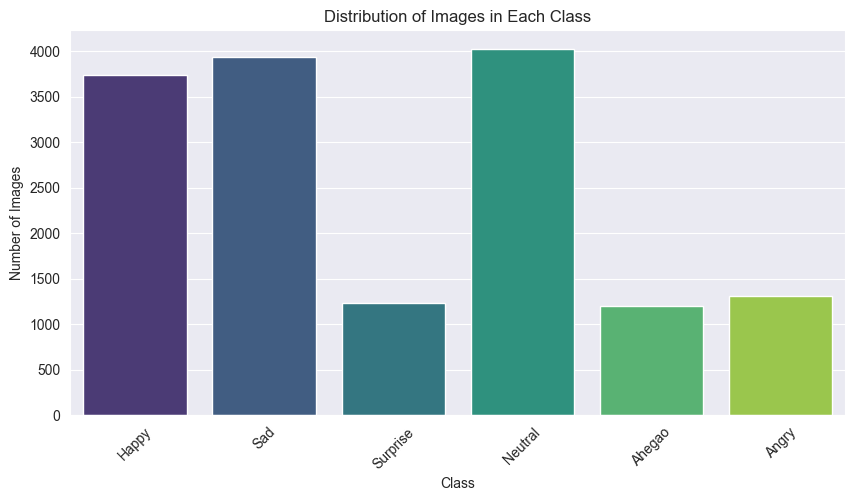

---------------Class Distribution---------------
0       Happy : 3740
1         Sad : 3934
2    Surprise : 1234
3     Neutral : 4027
4      Ahegao : 1205
5       Angry : 1313
dtype: object


In [101]:
# Make plot visualization of distribution of images of each class
data = []
for subdir in os.listdir(path_dataset):
    subdir_path = os.path.join(path_dataset, subdir)
    if os.path.isdir(subdir_path):
        num_images = len(os.listdir(subdir_path))
        data.append((subdir, num_images))
        
# Create a DataFrame from the data
df = pd.DataFrame(data, columns=['Class', 'Number of Images'])

# Plot the distribution of images
plt.figure(figsize=(10, 5))
sns.barplot(x='Class', y='Number of Images', data=df, palette='viridis')
plt.title('Distribution of Images in Each Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

print("---------------Class Distribution---------------")
print(df['Class'] + " : " + df['Number of Images'].astype(str))


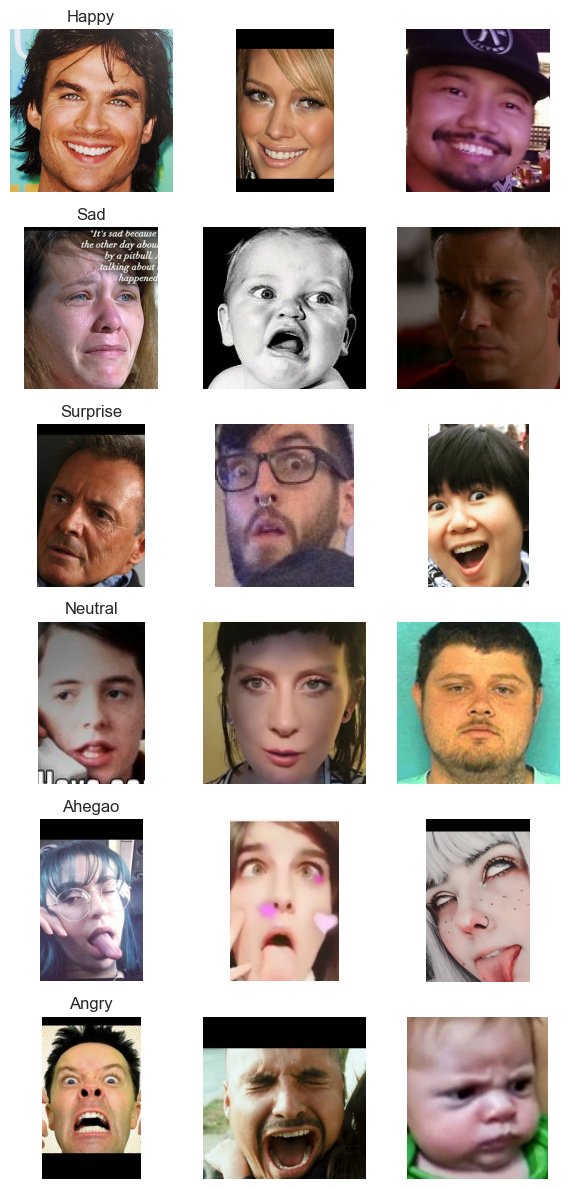

In [102]:
# Function to check sample of images in a directory
def check_images_from_df(df, num_images=5):
    # Check class on df
    class_name = df['Class'].unique()
    # Create a figure with subplots
    fig, ax = plt.subplots(len(class_name), num_images, figsize=(num_images * 2, len(class_name) * 2))
    
    # Loop through each class
    for i, class_name in enumerate(class_name):
        # Get the directory path for the class
        class_dir = os.path.join(path_dataset, class_name)
        
        # Get all image files in the directory
        image_files = os.listdir(class_dir)
        
        # Randomly sample image files
        sampled_files = sample(image_files, num_images)

        
        # Loop through each sampled file
        for j, img_file in enumerate(sampled_files):
            img_path = os.path.join(class_dir, img_file)
            ax[i, j].imshow(io.imread(img_path))
            ax[i, j].axis('off')
            
            if j == 0:
               ax[i, j].set_title(f"{class_name}")
                
    plt.tight_layout()
    plt.show()
        
            
check_images_from_df(df, num_images=3)

### Data Preprocessing

#### Data Augmentation

In [533]:
# Create function for anti-clockwise rotation
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    corner = random.randint(0,180)
    return rotate(img, corner)
 
# Create function for clockwise rotation
def clockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    corner = random.randint(0,180)
    return rotate(img, -corner)

# Create function to flip the image horizontally from left to right
def flip_left_right(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return np.fliplr(img)
 
# Create function to flip the image vertically from top to bottom
def flip_up_down(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return np.flipud(img)
 
# Create function to add brightness to the image
def add_brightness(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    img = adjust_gamma(img, gamma=0.5,gain=1)
    return img
 
# Create function to add blur to the image
def blur_image(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return cv2.GaussianBlur(img, (9,9),0)
 
# Create function to add shear to the image
def sheared(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(shear=0.2)
    shear_image = warp(img, transform, mode="wrap")
    return shear_image
 
# Create function to add warp shift to the image
def warp_shift(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(translation=(0,40))
    warp_image = warp(img, transform, mode="wrap")
    return warp_image

In [535]:
transform = {
    'anticlockwise_rotation': anticlockwise_rotation,
    'clockwise_rotation': clockwise_rotation,
    'flip_up_down': flip_up_down,
    'add_brightness': add_brightness,
    'blur_image': blur_image,
    'sheared': sheared,
    'warp_shift': warp_shift
}

# Find the largest class size
largest_class_size = df['Number of Images'].max()

# Generate augmented images for each target class to balance the dataset
for target_class in df['Class']:
  
     # Check if target class is maximum
    if df[df['Class'] == target_class]['Number of Images'].values[0] >= largest_class_size:
        continue
        
    class_dir = os.path.join(path_dataset, target_class)
    augmented_path = os.path.join(path_dataset, f"{target_class}_augmented")
    if not os.path.exists(augmented_path):
        os.makedirs(augmented_path)
        
    # Check if the class is already augmented
    if target_class.endswith('_augmented'):
            continue
    image_files = os.listdir(class_dir)
    images = [os.path.join(class_dir, img_file) for img_file in image_files]

    current_size = len(image_files)
    images_to_generate = largest_class_size - current_size
    i = 1

    while i <= images_to_generate:
        # Randomly select an image from the images list
        image = random.choice(images)

        if os.path.isfile(image):
            try:
                # Read the image
                original_image = io.imread(image)
                transform_image = None
                n = 0
                transformation_count = random.randint(1, len(transform))

                # Randomly select a transformation function
                while n < transformation_count:
                    transform_name = random.choice(list(transform.keys()))
                    transform_image = transform[transform_name](original_image)
                    n += 1

                new_image_path = os.path.join(augmented_path, f"augmented_image_{i}.jpg")
                transformed_image = img_as_ubyte(transform_image)
                cv2.imwrite(new_image_path, transformed_image)
                print(f"Augmented image {i} saved at {new_image_path}")

                i += 1

            except ValueError as e:
                print('Could not read the', image, ':', e, 'hence skipping it.')
        else:
            print(f"Skipping {image} as it is not a file.")

Augmented image 1 saved at data/1/dataset/Happy_augmented/augmented_image_1.jpg
Augmented image 2 saved at data/1/dataset/Happy_augmented/augmented_image_2.jpg
Augmented image 3 saved at data/1/dataset/Happy_augmented/augmented_image_3.jpg
Augmented image 4 saved at data/1/dataset/Happy_augmented/augmented_image_4.jpg
Augmented image 5 saved at data/1/dataset/Happy_augmented/augmented_image_5.jpg
Augmented image 6 saved at data/1/dataset/Happy_augmented/augmented_image_6.jpg
Augmented image 7 saved at data/1/dataset/Happy_augmented/augmented_image_7.jpg
Augmented image 8 saved at data/1/dataset/Happy_augmented/augmented_image_8.jpg
Augmented image 9 saved at data/1/dataset/Happy_augmented/augmented_image_9.jpg
Augmented image 10 saved at data/1/dataset/Happy_augmented/augmented_image_10.jpg
Augmented image 11 saved at data/1/dataset/Happy_augmented/augmented_image_11.jpg
Augmented image 12 saved at data/1/dataset/Happy_augmented/augmented_image_12.jpg
Augmented image 13 saved at data/1

Text(0.5, 1.0, 'Distribution of Images in Each Class After Augmentation')

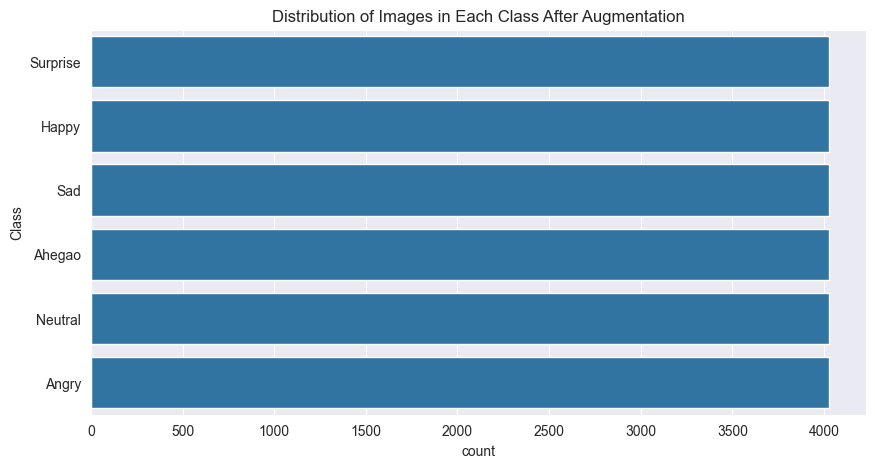

In [537]:
# Check the images after augmentation
# Create source path
source_path_dataset = 'data/1/dataset/'

# Create list for each name files, path file, and labels on source path
file_name = []
labels = []
full_path = []

# Get all the name files, path file, and labels and save it to dataframe
for path, subdirs, files in os.walk(source_path_dataset):
    for name in files:
        file_name.append(name)
        # Combine such as 'Angry' and 'Angry_augmented' labels
        label = path.split('/')[-1]
        if label.endswith('_augmented'):
            label = label.replace('_augmented', '')
        labels.append(label)
        full_path.append(os.path.join(path, name))

distribution = pd.DataFrame({'file_name': file_name, 'Class': labels, 'full_path': full_path})

# Plot the distribution of images
Label = distribution['Class']
plt.figure(figsize=(10, 5))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)
plt.title('Distribution of Images in Each Class After Augmentation')

#### Data Splitting

In [580]:
# Create variable for split dataset, X = data path, y = labels
X = distribution['full_path']
y = distribution['Class']

# Split the dataset into training, testing, and validation sets 50% train, 25% test, 25% validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Create DataFrame for training, testing, and validation sets
df_tr = pd.DataFrame({'path': X_train, 'labels': y_train,'set': 'train'})
df_te = pd.DataFrame({'path': X_test, 'labels': y_test,'set': 'test'})
df_val = pd.DataFrame({'path': X_val, 'labels': y_val,'set': 'validation'})

# Concatenate the three DataFrames
df_all = pd.concat([df_tr, df_te, df_val], axis=0)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')


set         labels  
test        Ahegao       824
            Angry        812
            Happy        769
            Neutral      794
            Sad          863
            Surprise     770
train       Ahegao      2415
            Angry       2408
            Happy       2417
            Neutral     2440
            Sad         2385
            Surprise    2432
validation  Ahegao       788
            Angry        807
            Happy        841
            Neutral      793
            Sad          779
            Surprise     825
dtype: int64 




In [581]:
# Check data
df_all.head(5)

,path,labels,set
18618,data/1/dataset/Ahegao/cropped_emotions.189698~...,Ahegao,train
10495,data/1/dataset/Ahegao_augmented/augmented_imag...,Ahegao,train
12964,data/1/dataset/Ahegao_augmented/augmented_imag...,Ahegao,train
3087,data/1/dataset/Happy/0c9313875e391a27946690b61...,Happy,train
22004,data/1/dataset/Angry_augmented/augmented_image...,Angry,train


In [582]:
# Create a directory final_dataset path 
final_dataset_path = 'data/final_dataset'
if not os.path.exists(final_dataset_path):
    os.makedirs(final_dataset_path, exist_ok=True)
    
# Move the dataset to the final_dataset path
for index, row in tq(df_all.iterrows()):
    file_path = row['path']
    if not os.path.exists(file_path):
        continue

    set_path = os.path.join(final_dataset_path, row['set'])
    class_path = os.path.join(set_path, row['labels'])

    if not os.path.exists(class_path):
        os.makedirs(class_path, exist_ok=True)   
        
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(final_dataset_path, row['set'], row['labels'], destination_file_name)
    
    # Check if the file already exists in the destination directory
    if not os.path.exists(file_dest):
        # Copy the file to the destination directory
        shutil.copy(file_path, file_dest)

0it [00:00, ?it/s]

In [583]:
# Define the path to the training, testing, and validation directories
train_dir = os.path.join(final_dataset_path, 'train')
test_dir = os.path.join(final_dataset_path, 'test')
val_dir = os.path.join(final_dataset_path, 'validation')


# Print total number of images in each set
print("Total number of images in the training set:")
for subdir in os.listdir(train_dir):
    subdir_path = os.path.join(train_dir, subdir)
    num_images = len(os.listdir(subdir_path))
    print(f"{subdir}: {num_images}")
print("\nTotal number of images in the testing set:")
for subdir in os.listdir(test_dir):
    subdir_path = os.path.join(test_dir, subdir)
    num_images = len(os.listdir(subdir_path))
    print(f"{subdir}: {num_images}")
print("\nTotal number of images in the validation set:")
for subdir in os.listdir(val_dir):
    subdir_path = os.path.join(val_dir, subdir)
    num_images = len(os.listdir(subdir_path))
    print(f"{subdir}: {num_images}")

Total number of images in the training set:
Happy: 2417
Sad: 2385
Surprise: 2432
Neutral: 2440
Ahegao: 2415
Angry: 2408

Total number of images in the testing set:
Happy: 769
Sad: 863
Surprise: 770
Neutral: 794
Ahegao: 824
Angry: 812

Total number of images in the validation set:
Happy: 841
Sad: 779
Surprise: 825
Neutral: 793
Ahegao: 788
Angry: 807


In [584]:
# Create object ImageDataGenerator for normalization and augmentation
target = (150, 150)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1/255.,  
    zoom_range=0.2,
    fill_mode='nearest',
)

test_datagen = ImageDataGenerator(rescale=1/255.)  # Only normalize test data

# Create generator for training set
train_generator = datagen.flow_from_directory(
    train_dir,
    batch_size=batch_size,
    target_size=target,
    class_mode='categorical',
    shuffle=True,
)

# Create generator for validation set
validation_generator = test_datagen.flow_from_directory(
    val_dir,
    batch_size=batch_size,
    target_size=target,
    class_mode='categorical',
    shuffle=False,
)

# Create generator for testing set
test_generator = test_datagen.flow_from_directory(
    test_dir,
    batch_size=batch_size,
    target_size=target,
    class_mode='categorical',
    shuffle=False,
)

Found 14497 images belonging to 6 classes.
Found 4833 images belonging to 6 classes.
Found 4832 images belonging to 6 classes.


## Modelling

In [595]:
pre_trained_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

for layer in pre_trained_model.layers[:100]:
    layer.trainable = False
for layer in pre_trained_model.layers[100:]:
    layer.trainable = True
    
# Create a Sequential model
model = Sequential()

# Add the base model
model.add(pre_trained_model)
# Add Convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
# Add Batch Normalization layer
model.add(BatchNormalization())

# Add Max Pooling layer
model.add(MaxPooling2D((2, 2)))
# # Add Convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
# Add Batch Normalization layer
model.add(BatchNormalization())
# Add Max Pooling layer
model.add(MaxPooling2D((2, 2)))


model.add(GlobalAveragePooling2D())
# Add Dropout layer
model.add(Dropout(0.5))
# Add Dense layer
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
# Add output layer
model.add(Dense(6, activation='softmax'))  # 6 classes
# Compile the model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Summary of the Model Architecture
print(model.summary())

Model: "sequential_68"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 5, 5, 1280)        2257984   
 tional)                                                         
                                                                 
 conv2d_137 (Conv2D)         (None, 5, 5, 32)          368672    
                                                                 
 batch_normalization_54 (Ba  (None, 5, 5, 32)          128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_135 (MaxPool  (None, 2, 2, 32)          0         
 ing2D)                                                          
                                                                 
 conv2d_138 (Conv2D)         (None, 2, 2, 64)          18496     
                                                     

In [601]:
# Callbacks
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, min_delta=0.0001, restore_best_weights=True, mode='max', baseline=0.95)

In [602]:
# Init epochs
epochs = 100


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

# Fit the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[checkpoint, lr_scheduler, early_stopping],
    verbose=1
)

Epoch 1/100
454/454 [==============================] - 98s 216ms/step - loss: 0.1929 - accuracy: 0.9396 - val_loss: 0.5989 - val_accuracy: 0.8390 - lr: 5.0000e-04
Epoch 2/100
454/454 [==============================] - 86s 190ms/step - loss: 0.1855 - accuracy: 0.9453 - val_loss: 1.2025 - val_accuracy: 0.7252 - lr: 5.0000e-04
Epoch 3/100
454/454 [==============================] - 90s 197ms/step - loss: 0.1744 - accuracy: 0.9487 - val_loss: 0.6477 - val_accuracy: 0.8361 - lr: 5.0000e-04
Epoch 4/100
454/454 [==============================] - ETA: 0s - loss: 0.1470 - accuracy: 0.9582
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
454/454 [==============================] - 85s 186ms/step - loss: 0.1470 - accuracy: 0.9582 - val_loss: 0.7596 - val_accuracy: 0.8179 - lr: 5.0000e-04
Epoch 5/100
454/454 [==============================] - 94s 207ms/step - loss: 0.1084 - accuracy: 0.9700 - val_loss: 0.5114 - val_accuracy: 0.8603 - lr: 2.5000e-04
Epoch 6/100
454/454 [===

In [603]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

# Print the testing accuracy
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

151/151 [==============================] - 14s 92ms/step - loss: 0.5765 - accuracy: 0.8580
Testing Accuracy: 85.80%


## Evaluation and Visualisation 

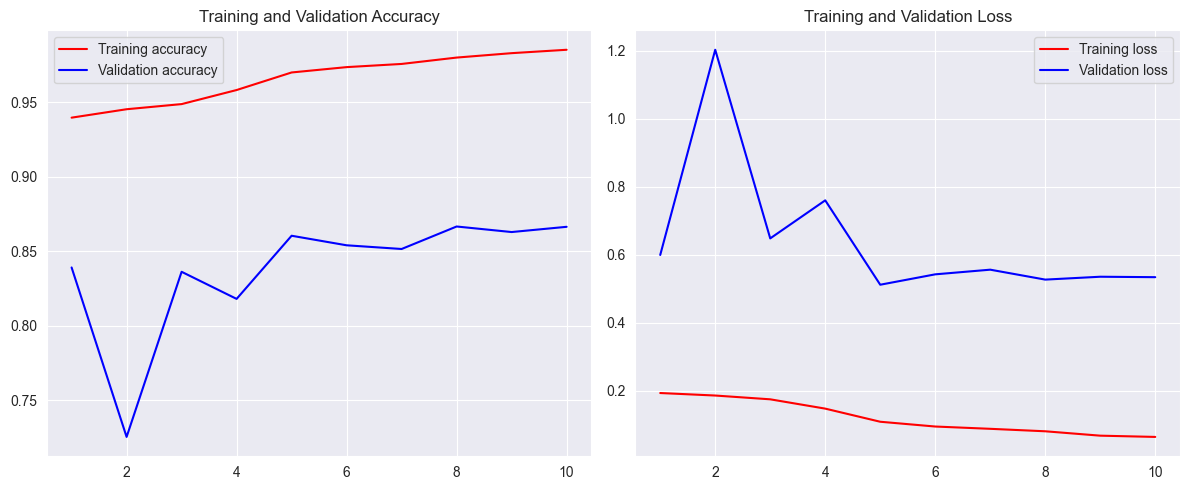

In [606]:
# Create plot for accuracy and plot for loss
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(1, len(acc) + 1)
    
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'r', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    

    plt.tight_layout()
    plt.show()
    
plot_training_history(history)    


## Model Conversion

### Convert the model to TFJS format

In [607]:
model.save("model.h5")

/Users/macbookpro/Library/CloudStorage/OneDrive-UniversitasIslamIndonesia/Dicoding/ImageClassificationFacialRecognition/.venv/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [608]:
# Install tensorflowjs
!pip install tensorflowjs
 
# Convert model.h5 to model
!tensorflowjs_converter --input_format=keras model.h5 tfjs_model

  Using cached tensorflow-2.19.0-cp39-cp39-macosx_12_0_arm64.whl.metadata (4.0 kB)
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
  Using cached tensorflow-2.16.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (4.1 kB)
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tensorstore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorstore to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C

### Convert the model to TensorFlow Lite format

In [609]:
# Convert the model to TensorFlow Lite format
converter_tf_lite = tf.lite.TFLiteConverter.from_keras_model(model)

# TFLite Model Conversion
tflite_model = converter_tf_lite.convert()

# Make directory for tflite model
if not os.path.exists('tflite_model'):
    os.makedirs('tflite_model')
    
# Save the TFLite model to a file
with open('tflite_model/model.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /var/folders/3q/m608zwdn7_3_d0cjdkbqsbm40000gn/T/tmpexmfk51a/assets


INFO:tensorflow:Assets written to: /var/folders/3q/m608zwdn7_3_d0cjdkbqsbm40000gn/T/tmpexmfk51a/assets
2025-04-12 14:45:29.304517: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2025-04-12 14:45:29.304591: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2025-04-12 14:45:29.309375: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/3q/m608zwdn7_3_d0cjdkbqsbm40000gn/T/tmpexmfk51a
2025-04-12 14:45:29.340148: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2025-04-12 14:45:29.340172: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/3q/m608zwdn7_3_d0cjdkbqsbm40000gn/T/tmpexmfk51a
2025-04-12 14:45:29.445872: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2025-04-12 14:45:29.456593: I tensorflow/cc/saved_model/load

In [611]:
# Create content for label file
label_file = 'tflite_model/labels.txt'
with open(label_file, 'w') as f:
    for label in train_generator.class_indices.keys():
        f.write(f"{label}\n")

### Convert the model to SavedModel format

In [610]:
# Make directory for saved_model
if not os.path.exists('saved_model'):
    os.makedirs('saved_model')
    
# Save the model in SavedModel format
model.save('saved_model/model')

INFO:tensorflow:Assets written to: saved_model/model/assets


INFO:tensorflow:Assets written to: saved_model/model/assets


## Inference

In [614]:
# Load the model using tflite_model
interpreter = tf.lite.Interpreter(model_path='tflite_model/model.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load the labels
with open(label_file, 'r') as f:
    labels = [line.strip() for line in f.readlines()]
    
# Function to load and preprocess the image
def load_and_preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((150, 150))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype(np.float32) / 255.0
    return img_array

# Function to make predictions using the TFLite model
def predict_image_tflite(image_path):
    img_array = load_and_preprocess_image(image_path)
    
    # Set the input tensor
    interpreter.set_tensor(input_details[0]['index'], img_array)
    
    # Run the inference
    interpreter.invoke()
    
    # Get the output tensor
    output_data = interpreter.get_tensor(output_details[0]['index'])
    
    # Get the predicted class
    predicted_class = labels[np.argmax(output_data)]
    
    return predicted_class, output_data

# Test the model with a sample image
test_image_path = 'data/final_dataset/test/Angry/f7c512f3769cc01ee8c3f2e4ef4ae8b718f8c6ec565385575e6926e4~angry.png'

predicted_class, predictions = predict_image_tflite(test_image_path)

# Print the predicted class and probabilities
print(f"Predicted class: {predicted_class}")
print("Predicted probabilities:")
for label, prob in zip(labels, predictions[0]):
    print(f"{label}: {prob:.4f}")
  

Predicted class: Angry
Predicted probabilities:
Ahegao: 0.0000
Angry: 0.9998
Happy: 0.0000
Neutral: 0.0001
Sad: 0.0000
Surprise: 0.0001


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
